In [44]:
#import libraries
import numpy as np
from ase.io import read, write
from ase import Atoms
import torch
import yaml
import json
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import re
#os.makedirs('img_res', exist_ok=True) #creates a folder to store the loss graphs
#os.makedirs('test_res', exist_ok=True) #creates a folder to store the files of the testing of the model
import functions as f #import functions used in this notebook

In [45]:
#variable setup
name = "Fe_Si_B_260311"
type = 'rnd_e'
frozen_layers = 4
device = 'cpu'
model = "MACE-matpes-pbe-omat-ft"
model_id = f'matpes_nofe8b4_freeze_{frozen_layers}'
learning_rate = 1e-4
num_epoch = 1 #number of epochs used for training
batch_size = 10 #batch size for training
seed = 123
folder = f'{model_id}_{learning_rate}_{num_epoch}_{batch_size}_{type}'
path = f'model_{name}/freeze_training/{folder}'
train_file = f"model_{name}/train_{type}.xyz"
test_file = f"model_{name}/test_{type}.xyz"
model_name = f'model_{type}_{model_id}_lr{learning_rate}_{num_epoch}_{batch_size}'
os.makedirs(path, exist_ok=True)
os.makedirs(f'{path}/img_res', exist_ok=True)
os.makedirs(f'{path}/test_res', exist_ok=True)
model_name

'model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_1_10'

In [46]:
#setting new names for the training and test files
structure = 'Fe8B4'
train_file = f"model_{name}/train_{type}_no_{structure}.xyz"
test_file = f"model_{name}/test_{type}_no_{structure}.xyz"

In [47]:
train_file

'model_Fe_Si_B_260311/train_rnd_e_no_Fe8B4.xyz'

In [48]:
#this writes the yml file
config = {
    'foundation_model': f'{model}.model',
    'multiheads_finetuning': False,
    'freeze': frozen_layers,
    "name": model_name,
    "model_dir": path,
    "log_dir": f"{path}/log",
    "checkpoints_dir": f"{path}/checkpoints",
    "results_dir": f"{path}/results",
    "train_file": train_file,
    "valid_fraction": 0.1,
    "test_file": test_file,
    "energy_key": "REF_energy",
    "forces_key": "REF_forces",
    "batch_size": batch_size,
    "max_num_epochs": num_epoch,
    "lr":learning_rate,
    "device": device,
    "seed": seed,
}
with open(f"model_{name}/config_freeze.yml", "w") as f:
    yaml.dump(config, f, sort_keys=False)

In [49]:
#Perform training
import warnings
warnings.filterwarnings('ignore')
from mace.cli.run_train import main as mace_run_train_main
import sys
import logging

#defining the training function
def train_mace(config_file_path):
    logging.getLogger().handlers.clear()
    sys.argv = ['program', '--config', config_file_path]
    mace_run_train_main()

#calling the function
train_mace(f'model_{name}/config_freeze.yml') # use the name of the config file that was created

2026-06-11 19:07:17.263 INFO: ===========VERIFYING SETTINGS===========
2026-06-11 19:07:17.264 INFO: MACE version: 0.3.14
2026-06-11 19:07:17.265 INFO: Using CPU
2026-06-11 19:07:17.548 INFO: Using foundation model MACE-matpes-pbe-omat-ft.model as initial checkpoint.
2026-06-11 19:07:17.550 WARNING: Using multiheads finetuning with a foundation model that is not a Materials Project model, need to provied a path to a pretraining file with --pt_train_file.
2026-06-11 19:07:17.550 INFO: ===========LOADING INPUT DATA===========
2026-06-11 19:07:17.551 INFO: Using heads: ['Default']
2026-06-11 19:07:17.552 INFO: Using the key specifications to parse data:
2026-06-11 19:07:17.552 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'cha

In [50]:
#reading the information on the results file
results = f'{path}/results/{model_name}_run-{seed}_train.txt' #reading the file where the training results is stored
data = [] #where the data from the 'results' file will be stored
with open(results, 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue
results

'model_Fe_Si_B_260311/freeze_training/matpes_nofe8b4_freeze_4_0.0001_1_10_rnd_e/results/model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_1_10_run-123_train.txt'

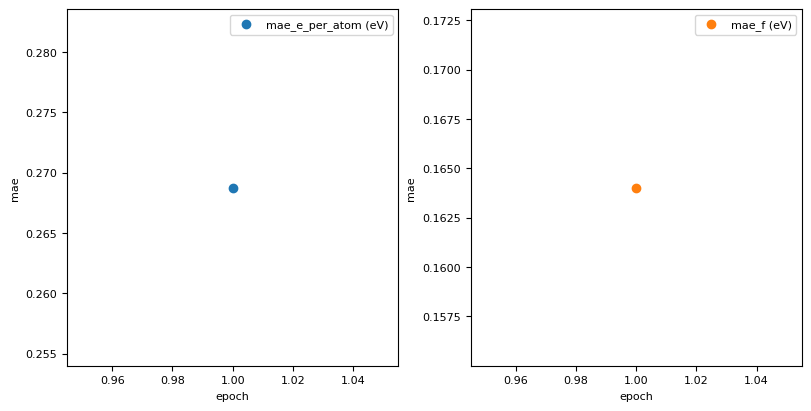

In [51]:
df = pd.DataFrame(data)
#separating the training and validation results
train_df = df[df['mode']=='opt'].copy()
val_df = df[df['mode']=='eval'].copy().dropna()
#train_df = train_df.groupby('epoch', as_index=False)['loss'].last()
train_df = train_df.groupby('epoch', as_index=False)['loss'].mean()
train_df['epoch'] += 1
val_df['epoch'] += 1

#plotting the dataframe
import functions as f
f.plot_mae(val_df, 'epoch', ['mae_e_per_atom','mae_f'])

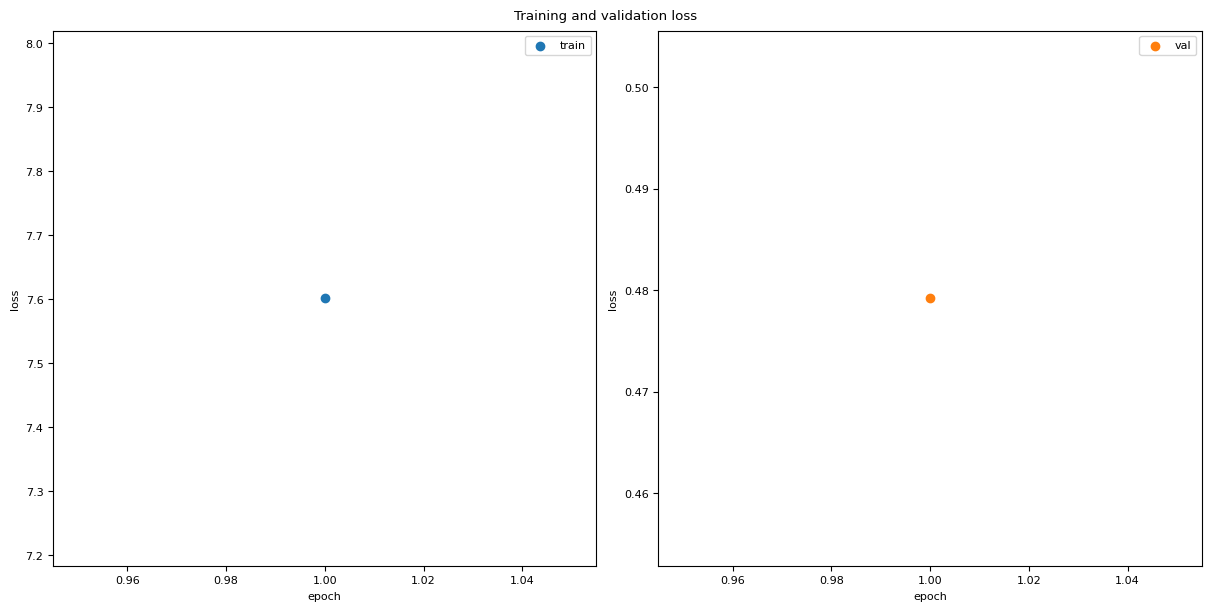

In [52]:
f.plot_loss([(train_df, 'train'),(val_df,'val')],'epoch','loss',model_name, path)

In [27]:
#evaluation
from mace.cli.eval_configs import main as mace_eval_configs_main
import sys

def eval_mace(model, configs, output, device=device):
    #agregue esto para liberar memoria (a ver que tal)
    if device == 'cpu':
        torch.cuda.empty_cache()
        batch_size = '1'

    sys.argv=['program', '--configs', configs, '--model', model, '--output', output, '--device', device, '--batch_size', batch_size]
    mace_eval_configs_main()

In [53]:
model_name

'model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_1_10'

In [29]:
#evaluating the set on both the training and test datasets
eval_mace(model=f'{path}/{model_name}.model',
          configs=train_file,
          output=f'{path}/test_res/{model_name}_train.xyz')

eval_mace(model=f'{path}/{model_name}.model',
          configs=test_file,
          output=f'{path}/test_res/{model_name}_test.xyz')

2026-06-11 15:28:14.886 INFO: Using CPU
2026-06-11 15:34:05.557 INFO: Using CPU


In [30]:
test_df = f.eval_read(model_name, 'test', path)
train_df = f.eval_read(model_name, 'train', path)
train_df = train_df[3:] #this is to not include the first three configuratiosn which are the isolated atoms
test_df1 = test_df[['config', 'n_atoms', 'REF_energy', 'MACE_energy', 'REF_e/atom_meV', 'MACE_e/atom_meV']].copy()
train_df1 = train_df[['config', 'n_atoms', 'REF_energy', 'MACE_energy', 'REF_e/atom_meV', 'MACE_e/atom_meV']].copy()
train_df2 = f.forces(train_df)
test_df2 = f.forces(test_df)

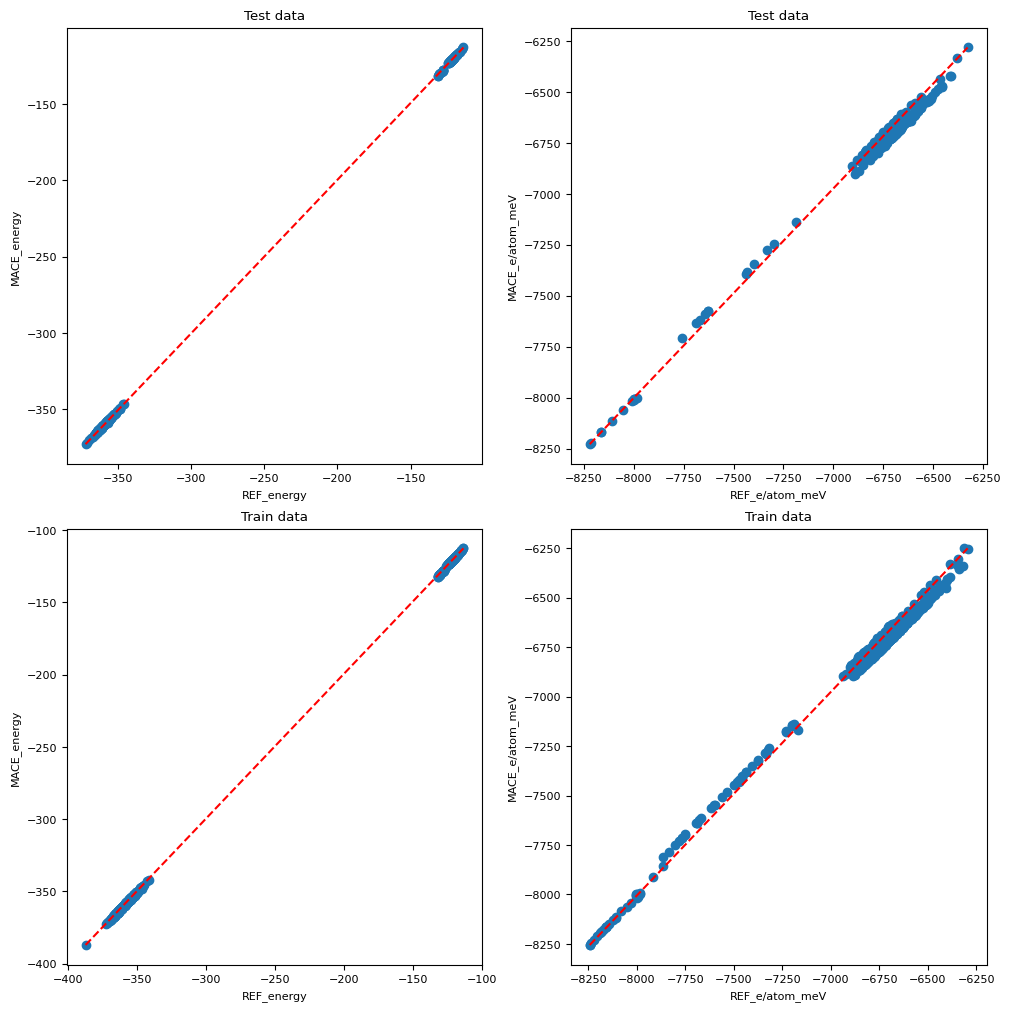

In [31]:
f.plot_comparison([test_df1, train_df1], 
                  ['REF_energy', 'REF_e/atom_meV'], ['MACE_energy','MACE_e/atom_meV'], ['Test data', 'Train data'], 'energy', model_name, path)

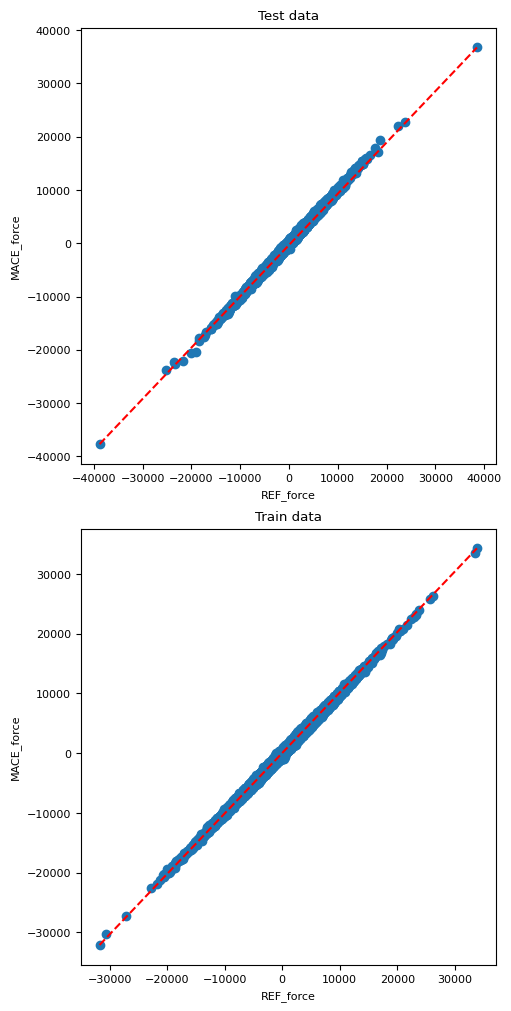

In [32]:
f.plot_comparison([test_df2, train_df2], 
                  ['REF_force'], ['MACE_force'], ['Test data', 'Train data'], 'forces', model_name, path)

In [33]:
ref = 'REF_e/atom_meV'
pred = 'MACE_e/atom_meV'
test_error = f.errors(test_df, 'test_energy', ref, pred)
train_error = f.errors(train_df, 'train_energy', ref, pred)
e_errors = pd.concat([test_error, train_error])
test_config_error = f.config_errors(test_df, 'test_energy', ref, pred)
train_config_error = f.config_errors(train_df, 'train_energy', ref, pred)
config_errors = pd.concat([test_config_error, train_config_error])
ref = 'REF_force'
pred = 'MACE_force'
test_error = f.errors(test_df2, 'test_force', ref, pred)
train_error = f.errors(train_df2, 'train_force', ref, pred)
f_errors = pd.concat([test_error, train_error])
errors = pd.concat([e_errors,f_errors])
errors

,error,rmse,mae,r2
0,test_energy,26.630613,22.128958,0.995091
0,train_energy,24.258079,19.841781,0.995637
0,test_force,172.530838,130.484230,0.996228
0,train_force,163.206760,125.028261,0.996601


In [34]:
#saving to an excel file so that we can keep a register of how different the resuls are for the different models
with pd.ExcelWriter(f'{path}/test_res/{model_name}_test.xlsx') as writer:
    test_df1.to_excel(writer, sheet_name='test_predictions')
    train_df1.to_excel(writer, sheet_name='train_predictions')
    errors.to_excel(writer, sheet_name='errors')
    config_errors.to_excel(writer, sheet_name='config_errors')

In [1]:
!python freeze_training_continous.py

^C


In [3]:
!python fine_tuning_continuous.py

c:\Users\Hirayama-Lab\.conda\envs\mace_gpu_test\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Traceback (most recent call last):
  File "f:\Shannon\Mygithub\research_files\new_model\fine_tuning_continuous.py", line 126, in <module>
    with open(results, 'r') as f_res:
FileNotFoundError: [Errno 2] No such file or directory: 'model_Fe_Si_B_260311/freeze_training/matpes_nofe8b4_0.0001_40_10_rnd_e/results/model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_run-123_train.txt'


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-06-16 17:53:58.721 INFO: ===========VERIFYING SETTINGS===========
2026-06-16 17:53:58.721 INFO: MACE version: 0.3.14
2026-06-16 17:53:58.722 INFO: Using CPU
2026-06-16 17:53:59.155 INFO: Using foundation model MACE-matpes-pbe-omat-ft.model as initial checkpoint.
2026-06-16 17:53:59.155 WARNING: Using multiheads finetuning with a foundation model that is not a Materials Project model, need to provied a path to a pretraining file with --pt_train_file.
2026-06-16 17:53:59.155 INFO: ===========LOADING INPUT DATA===========
2026-06-16 17:53:59.155 INFO: Using heads: ['Default']
2026-06-16 17:53:59.155 INFO: Using the key specifications to parse data:
2026-06-16 17:53:59.156 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'po

c:\Users\Hirayama-Lab\.conda\envs\mace_gpu_test\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
